In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import ConnectionPatch
import scipy.stats

In [2]:
sim = Simulation("Flatfielding")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

In [3]:
# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Enable flatfielding

sim["CCD/IncludeFlatfield"] = "yes"
rms = sim["CCD/FlatfieldNoiseRMS"]

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

sim["ControlHDF5Content/WriteSubPixelImages"] = "true"

output = sim.run(removeOutputFile = True)

image = output.getImage(0)


2020-05-18 13:39:41 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-18 13:39:42 WARNING Camera: No star positions to write to HDF5 file.



# PRNU derived directly from the image

In [4]:
mean = np.mean(image)
prnuFromImage = math.sqrt(np.mean((image - mean)**2)) / mean

print("PRNU derived from PlatoSim output:", prnuFromImage)
print("To compare with input value in the configuration file:", rms)

PRNU derived from PlatoSim output: 0.010100033723960107
To compare with input value in the configuration file: 0.01


# Flatfield map

In [5]:
flatfield = output.getPRNU()

## Histogram

(0.97, 1.03)

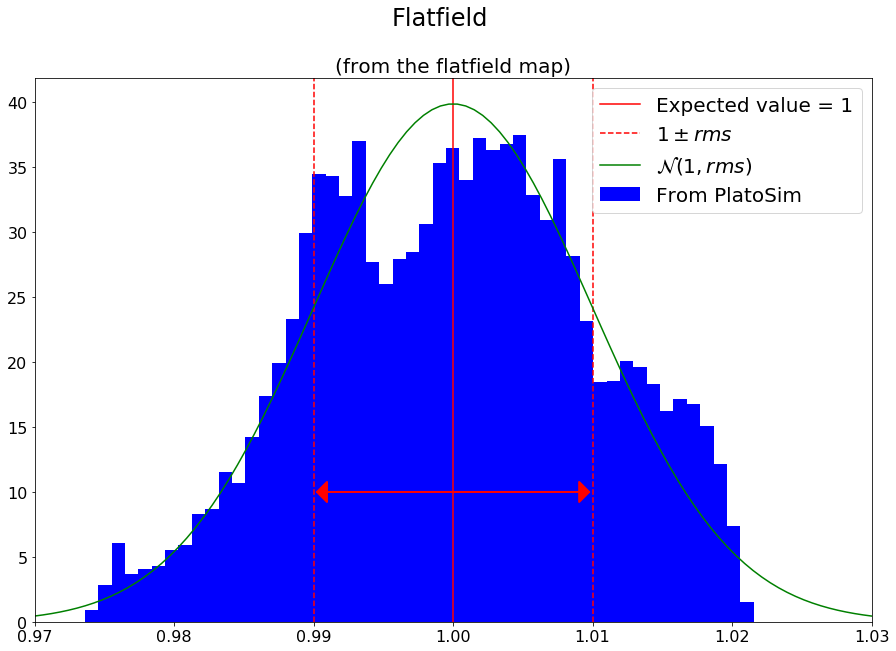

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.hist(np.ravel(flatfield), 50, density = True, color = "b", label = "From PlatoSim")



#################
# Expected values
#################

plt.axvline(x = 1, color = "r", label = "Expected value = 1")
plt.axvline(x = 1 - rms, color ="r", linestyle = "dashed", label = "$1 \\pm rms$")
plt.axvline(x = 1 + rms, color = "r", linestyle = "dashed")
ax.annotate("",
            xy=(1 - rms, 10), xycoords='data',
            xytext=(1 + rms, 10), textcoords='data',
            arrowprops=dict(arrowstyle="<|-|>, head_width = 1, head_length = 1",
                            connectionstyle="arc3", color="r", lw="2")
            )

mu = 1.0
sigma = rms
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, scipy.stats.norm.pdf(x, mu, sigma), "g", label="$\mathcal{N} (1, rms)$")



########
# Layout
########

plt.suptitle("Flatfield", fontsize = 24)
plt.title("(from the flatfield map)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.xlim([0.97, 1.03])

## Mean & standard deviation

In [7]:
meanFromFlatfieldMap = np.mean(flatfield)
stdDevFromFlatfieldMap = np.std(flatfield)

print("Mean from flatfield map:", meanFromFlatfieldMap)
print("To compare with expected value:", 1, "\n")

print("Standard deviation from flatfield map:", stdDevFromFlatfieldMap)
print("To compare with input value in the configuration file:", rms)

Mean from flatfield map: 0.99998665
To compare with expected value: 1 

Standard deviation from flatfield map: 0.0100999
To compare with input value in the configuration file: 0.01


## 1 / f dependency

In [8]:
fft = np.fft.fft2(flatfield)
realPart = np.real(fft)

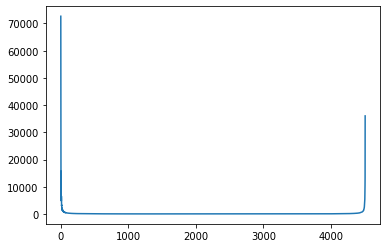

In [9]:
power = np.abs(fft)
plt.plot(power[1])

# Comparison

In [10]:
image = output.getImage(0)

sim["CCD/IncludeFlatfield"] = "no"
output = sim.run(removeOutputFile = True)
refImage = output.getImage(0)


2020-05-18 13:39:45 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-18 13:39:45 WARNING Camera: No star positions to write to HDF5 file.



In [11]:
quotient = image / refImage

(0.97, 1.03)

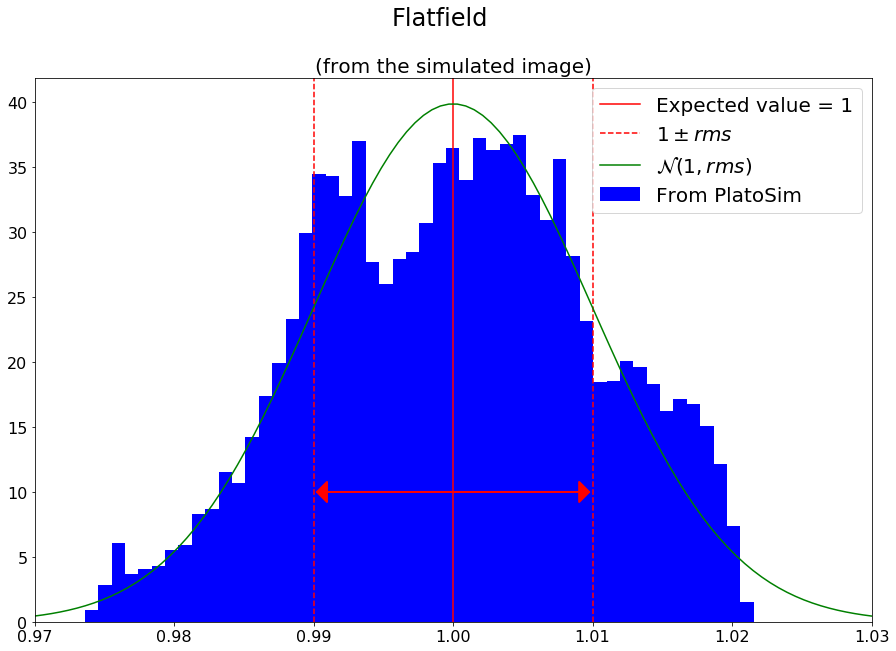

In [12]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.hist(np.ravel(quotient), 50, density = True, color = "b", label = "From PlatoSim")



#################
# Expected values
#################

plt.axvline(x = 1, color = "r", label = "Expected value = 1")
plt.axvline(x = 1 - rms, color ="r", linestyle = "dashed", label = "$1 \\pm rms$")
plt.axvline(x = 1 + rms, color = "r", linestyle = "dashed")
ax.annotate("",
            xy=(1 - rms, 10), xycoords='data',
            xytext=(1 + rms, 10), textcoords='data',
            arrowprops=dict(arrowstyle="<|-|>, head_width = 1, head_length = 1",
                            connectionstyle="arc3", color="r", lw="2")
            )

mu = 1.0
sigma = rms
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, scipy.stats.norm.pdf(x, mu, sigma), "g", label="$\mathcal{N} (1, rms)$")



########
# Layout
########

plt.suptitle("Flatfield", fontsize = 24)
plt.title("(from the simulated image)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0.97, 1.03])